In [9]:
# Task 1 - Data Cleaning & Preprocessing
# Elevate Labs AI & ML Internship
# Done by: Eswar K (Mumbai)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

# Loading the dataset (I downloaded Titanic from the link they gave)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded! Shape:", df.shape)
df.head()

Libraries imported successfully!
Dataset loaded! Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Step 2: Handling missing values
# I first tried mean for Age but median is better for age (less affected by outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())

# For Embarked, mode makes sense because it's categorical
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin has way too many missing (almost 77%), so dropping it
df = df.drop(columns=['Cabin'])

print("Missing values after handling:")
print(df.isnull().sum())
print("✅ Missing values fixed!")

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
✅ Missing values fixed!


In [6]:
# Step 3: Encoding categorical features
# Dropping columns that won't help in ML (Name, Ticket, PassengerId)
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

# Sex - simple mapping (I prefer this over label encoder for binary)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked - One hot encoding (drop_first to avoid dummy trap)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("After encoding:")
print(df.head())
print("\nColumns now:", df.columns.tolist())

After encoding:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True

Columns now: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


In [7]:
# Step 4: Standardizing numerical features (I used Z-score manually with NumPy)
numerical = ['Age', 'Fare']

for col in numerical:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df[col] = (df[col] - mean_val) / std_val
    print(f"Standardized {col}")

print("✅ Features standardized!")
df.head()

Standardized Age
Standardized Fare
✅ Features standardized!


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,-0.565419,1,0,-0.502163,False,True
1,1,1,1,0.663488,1,0,0.786404,False,False
2,1,3,1,-0.258192,0,0,-0.488580,False,True
3,1,1,1,0.433068,1,0,0.420494,False,True
4,0,3,0,0.433068,0,0,-0.486064,False,True


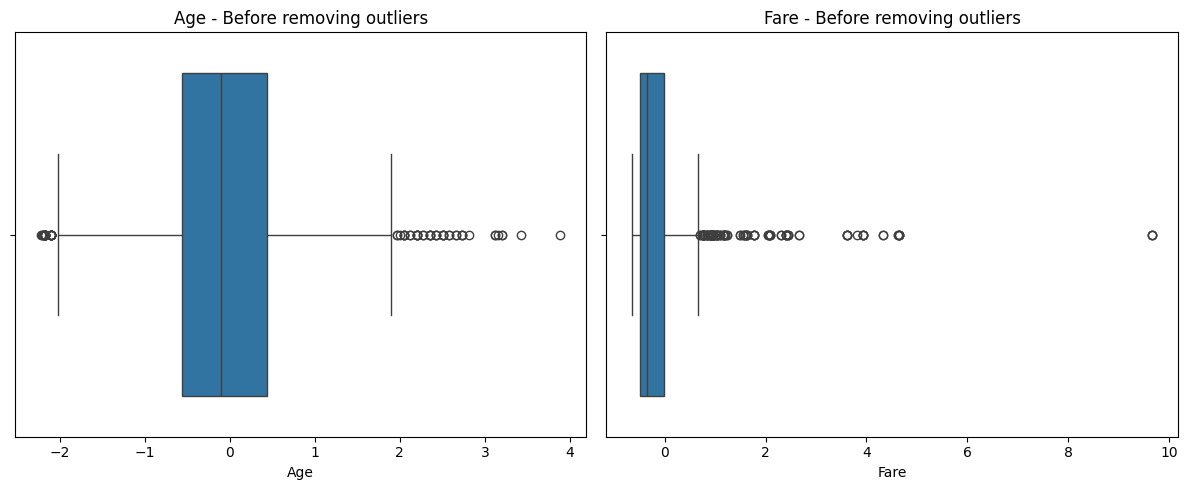

Original rows: 891
After removing outliers: 718
Outliers removed successfully!


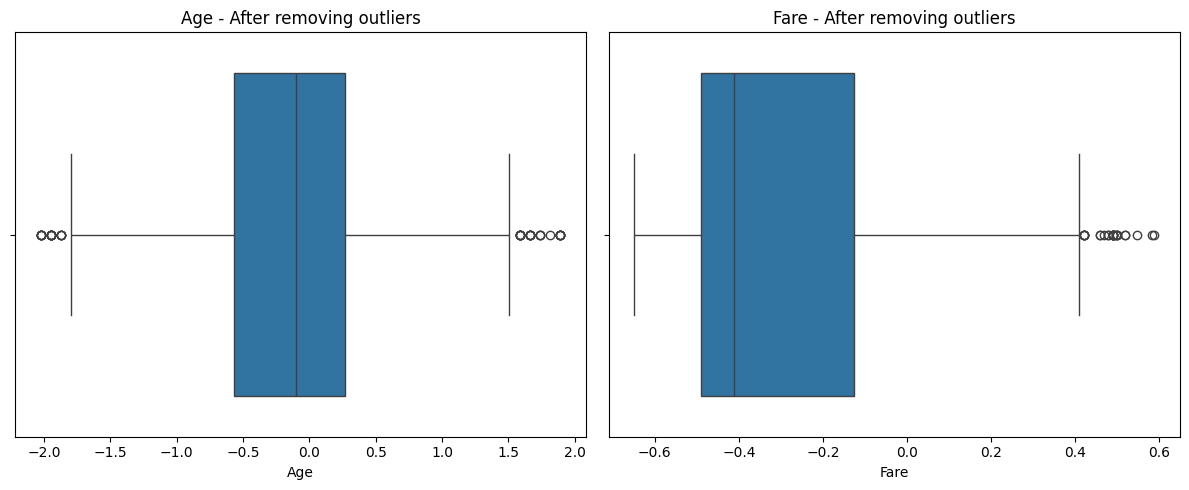

🎉 All done! Files saved for submission.


In [8]:
# Step 5: Visualizing and removing outliers using boxplots + IQR

# Boxplots before
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['Age'])
plt.title('Age - Before removing outliers')
plt.subplot(1,2,2)
sns.boxplot(x=df['Fare'])
plt.title('Fare - Before removing outliers')
plt.tight_layout()
plt.savefig('outliers_before.png')
plt.show()

# IQR method (I tried 1.5 * IQR as taught in tutorials)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df_clean = remove_outliers(df, 'Age')
df_clean = remove_outliers(df_clean, 'Fare')

print(f"Original rows: {len(df)}")
print(f"After removing outliers: {len(df_clean)}")
print("Outliers removed successfully!")

# Boxplots after
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df_clean['Age'])
plt.title('Age - After removing outliers')
plt.subplot(1,2,2)
sns.boxplot(x=df_clean['Fare'])
plt.title('Fare - After removing outliers')
plt.tight_layout()
plt.savefig('outliers_after.png')
plt.show()

# Save the final cleaned data
df_clean.to_csv('titanic_cleaned.csv', index=False)
print("🎉 All done! Files saved for submission.")